
SIMON'S ALGORITHM - 4-BIT SECRET
Secret string: 1011

QUANTUM CIRCUIT
          ┌───┐ ░                           ░ ┌───┐ ░ ┌─┐         
 input_0: ┤ H ├─░───■───────────────────────░─┤ H ├─░─┤M├─────────
          ├───┤ ░   │                       ░ ├───┤ ░ └╥┘┌─┐      
 input_1: ┤ H ├─░───┼────■──────────────────░─┤ H ├─░──╫─┤M├──────
          ├───┤ ░   │    │                  ░ ├───┤ ░  ║ └╥┘┌─┐   
 input_2: ┤ H ├─░───┼────┼────■─────────────░─┤ H ├─░──╫──╫─┤M├───
          ├───┤ ░   │    │    │             ░ ├───┤ ░  ║  ║ └╥┘┌─┐
 input_3: ┤ H ├─░───┼────┼────┼────■────■───░─┤ H ├─░──╫──╫──╫─┤M├
          └───┘ ░ ┌─┴─┐  │    │  ┌─┴─┐  │   ░ └───┘ ░  ║  ║  ║ └╥┘
output_0: ──────░─┤ X ├──┼────┼──┤ X ├──┼───░───────░──╫──╫──╫──╫─
                ░ └───┘┌─┴─┐  │  └───┘  │   ░       ░  ║  ║  ║  ║ 
output_1: ──────░──────┤ X ├──┼─────────┼───░───────░──╫──╫──╫──╫─
                ░      └───┘┌─┴─┐     ┌─┴─┐ ░       ░  ║  ║  ║  ║ 
output_2: ──────░───────────┤ X ├─────┤ X ├─░───────░──╫──

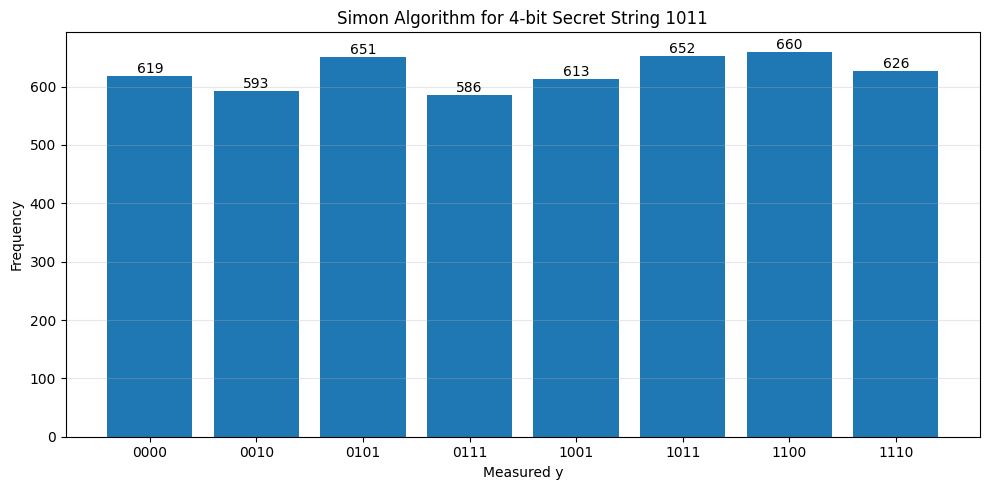

In [4]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.primitives import StatevectorSampler

SECRET = "1011"
N = len(SECRET)
SHOTS = 5000

q_in = QuantumRegister(N, "input")
q_out = QuantumRegister(N, "output")
c = ClassicalRegister(N, "meas")

qc = QuantumCircuit(q_in, q_out, c)

# Step 1: Put input qubits into superposition
for i in range(N):
    qc.h(q_in[i])

qc.barrier()

# Step 2: Simon oracle for secret 1011
#
# f(x) = (x0 XOR x3, x1, x2 XOR x3, 0)
#
# Since secret = 1011:
# x0 XOR x3
# x1
# x2 XOR x3
# 0

qc.cx(q_in[0], q_out[0])
qc.cx(q_in[3], q_out[0])

qc.cx(q_in[1], q_out[1])

qc.cx(q_in[2], q_out[2])
qc.cx(q_in[3], q_out[2])

qc.barrier()

# Step 3: Apply Hadamard again
for i in range(N):
    qc.h(q_in[i])

qc.barrier()

# Step 4: Measure only input register
for i in range(N):
    qc.measure(q_in[i], c[i])

print("\nSIMON'S ALGORITHM - 4-BIT SECRET")
print("=" * 65)
print("Secret string:", SECRET)

print("\nQUANTUM CIRCUIT")
print("=" * 65)
print(qc.draw())

# Step 5: Run circuit
sampler = StatevectorSampler()

result = sampler.run(
    [qc],
    shots=SHOTS
).result()

# Step 6: Version-safe measurement extraction
data = result[0].data

register_names = list(data.keys())

if "meas" in register_names:
    counts = data["meas"].get_counts()
else:
    counts = data[register_names[0]].get_counts()

print("\nMEASUREMENT RESULTS")
print("=" * 65)
print("Shots :", SHOTS)
print("Counts:", counts)

# Step 7: Find valid Simon equations
valid_equations = []

for y in counts:
    y = y[::-1]

    if y == "0000":
        continue

    dot_product = 0

    for i in range(N):
        dot_product += int(y[i]) * int(SECRET[i])

    dot_product = dot_product % 2

    if dot_product == 0:
        if y not in valid_equations:
            valid_equations.append(y)

print("\nSIMON EQUATIONS")
print("=" * 65)

for y in valid_equations:
    print(y, " . ", SECRET, " = 0 (mod 2)")

# Step 8: Select independent equations using GF(2)
def gf2_rank(rows):
    if len(rows) == 0:
        return 0

    matrix = [
        [int(bit) for bit in row]
        for row in rows
    ]

    rows_count = len(matrix)
    cols_count = len(matrix[0])
    rank = 0

    for col in range(cols_count):
        pivot = None

        for row in range(rank, rows_count):
            if matrix[row][col] == 1:
                pivot = row
                break

        if pivot is None:
            continue

        matrix[rank], matrix[pivot] = matrix[pivot], matrix[rank]

        for row in range(rows_count):
            if row != rank and matrix[row][col] == 1:
                for j in range(col, cols_count):
                    matrix[row][j] ^= matrix[rank][j]

        rank += 1

    return rank

independent = []

for equation in valid_equations:
    test = independent + [equation]

    if gf2_rank(test) > gf2_rank(independent):
        independent.append(equation)

    if len(independent) >= N - 1:
        break

print("\nINDEPENDENT EQUATIONS")
print("=" * 65)

for equation in independent:
    print(equation)

# Step 9: Verify the secret
print("\nGF(2) LINEAR SYSTEM")
print("=" * 65)

for equation in independent:
    terms = []

    for i in range(N):
        if equation[i] == "1":
            terms.append("s" + str(i))

    if len(terms) == 0:
        expression = "0"
    else:
        expression = " + ".join(terms)

    print(expression, "= 0 (mod 2)")

print("\nSECRET VERIFICATION")
print("=" * 65)

verification = True

for equation in independent:
    value = 0

    for i in range(N):
        value += int(equation[i]) * int(SECRET[i])

    value = value % 2

    if value != 0:
        verification = False

if verification and len(independent) >= N - 1:
    print("All independent equations satisfy y . s = 0.")
    print("Recovered secret string:", SECRET)
    print("Secret string verified successfully.")
else:
    print("More independent equations are required.")

# Step 10: Measurement graph
labels = sorted(counts.keys())
values = [counts[label] for label in labels]

plt.figure(figsize=(10, 5))

bars = plt.bar(labels, values)

plt.xlabel("Measured y")
plt.ylabel("Frequency")
plt.title("Simon Algorithm for 4-bit Secret String 1011")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()